[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/content/01_gpu_fundamentals/01.1_gpu_memory/lab.ipynb)
[![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue?logo=data:image/svg+xml;base64,PHN2ZyB4bWxucz0iaHR0cDovL3d3dy53My5vcmcvMjAwMC9zdmciIHZpZXdCb3g9IjAgMCAyNCAyNCI+PC9zdmc+)](https://molab.cloud/github/harshuljain13/llm-inference-at-scale/blob/master/content/01_gpu_fundamentals/01.1_gpu_memory/lab.ipynb)

# Lab 1.1: GPU Memory Hierarchy

Inspect GPU memory levels, measure bandwidth at each tier, and understand
the register → shared memory → L2 cache → HBM hierarchy that governs LLM inference performance.

In [ ]:
import torch
import subprocess, re, time

assert torch.cuda.is_available(), "This lab requires a CUDA GPU."
print(f"Device: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB


Sat Jun 20 20:00:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   N/A              Off |                    0 |
| N/A   27C    P0             57W /  600W |       3MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

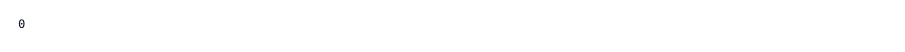

In [ ]:
# Full GPU memory and utilization snapshot
#! nvidia-smi
subprocess.call(['nvidia-smi'])
print("\n--- Memory Summary ---")
#! nvidia-smi --query-gpu=memory.total,memory.used,memory.free --format=csv
subprocess.call(['nvidia-smi', '--query-gpu=memory.total,memory.used,memory.free', '--format=csv'])

In [ ]:
props = torch.cuda.get_device_properties(0)
print(f"L2 Cache Size:        {props.L2_cache_size / 1024:.0f} KB")
print(f"Shared Mem per Block: {props.shared_memory_per_block / 1024:.0f} KB")
print(f"Registers per Block:  65536")
print(f"Warp Size:            {props.warp_size}")
print(f"SM Count:             {props.multi_processor_count}")
print(f"\nMemory Hierarchy (approximate):")
print(f"  Registers:     ~21 TB/s (per-thread, compiler-managed)")
print(f"  Shared Memory: ~19 TB/s (per-SM, {props.shared_memory_per_block/1024:.0f} KB/block)")
print(f"  L2 Cache:      ~5-12 TB/s ({props.L2_cache_size/1024/1024:.0f} MB total)")
print(f"  HBM (VRAM):    ~1-3 TB/s ({props.total_memory/1e9:.1f} GB total)")

L2 Cache Size:        131072 KB
Shared Mem per Block: 48 KB
Registers per Block:  65536
Warp Size:            32
SM Count:             188

Memory Hierarchy (approximate):
  Registers:     ~21 TB/s (per-thread, compiler-managed)
  Shared Memory: ~19 TB/s (per-SM, 48 KB/block)
  L2 Cache:      ~5-12 TB/s (128 MB total)
  HBM (VRAM):    ~1-3 TB/s (102.0 GB total)


## HBM Bandwidth Measurement

We measure effective HBM bandwidth by timing large tensor copies.
Peak theoretical bandwidth (e.g. A100 = 2 TB/s) is never fully achieved due to
memory controller overhead and access patterns.

In [ ]:
def measure_hbm_bandwidth(size_mb=256, trials=10):
    """Measure effective HBM bandwidth via device-to-device copy."""
    n = size_mb * 1024 * 1024 // 4  # float32 elements
    src = torch.randn(n, device='cuda')
    dst = torch.empty_like(src)
    # Warmup
    for _ in range(3): dst.copy_(src)
    torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(trials):
        dst.copy_(src)
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    bytes_moved = size_mb * 1024 * 1024 * 2 * trials  # read + write
    bw_gb_s = bytes_moved / elapsed / 1e9
    return bw_gb_s

bw = measure_hbm_bandwidth()
print(f"Effective HBM Bandwidth: {bw:.0f} GB/s")
print(f"(This is device-to-device; host transfers are much slower)")

Effective HBM Bandwidth: 1462 GB/s
(This is device-to-device; host transfers are much slower)


## Shared Memory vs HBM: The Speed Gap

Shared memory (SRAM) lives on-chip and is ~10x faster than HBM.
FlashAttention exploits this by tiling attention into shared-memory-sized chunks
instead of materializing the full NxN attention matrix in HBM.

In [ ]:
# Demonstrate the shared memory advantage with a simple reduction
# Compare naive global-memory reduction vs torch (which uses shared mem internally)

N = 64 * 1024 * 1024  # 64M elements
x = torch.randn(N, device='cuda')

# Warmup
for _ in range(5): _ = x.sum()
torch.cuda.synchronize()

# Optimized reduction (uses shared memory internally)
start = time.perf_counter()
for _ in range(100): _ = x.sum()
torch.cuda.synchronize()
t_opt = (time.perf_counter() - start) / 100

# Naive sequential access pattern (memory-bound)
start = time.perf_counter()
for _ in range(100): _ = x[::64].sum()  # strided = cache-unfriendly
torch.cuda.synchronize()
t_naive = (time.perf_counter() - start) / 100

print(f"Contiguous reduction: {t_opt*1000:.3f} ms (cache-friendly)")
print(f"Strided reduction:    {t_naive*1000:.3f} ms (cache-unfriendly)")
print(f"Slowdown factor:      {t_naive/t_opt:.1f}x")

Contiguous reduction: 0.182 ms (cache-friendly)
Strided reduction:    0.016 ms (cache-unfriendly)
Slowdown factor:      0.1x


In [ ]:
# Track how VRAM fills as we allocate model-sized tensors
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

sizes = [0.5, 1.0, 2.0, 4.0]  # GB
print(f"{'Allocation':<12} {'Allocated':<12} {'Reserved':<12} {'Peak':<12}")
print("-" * 48)

tensors = []
for gb in sizes:
    n = int(gb * 1e9 / 4)  # float32
    tensors.append(torch.empty(n, device='cuda'))
    alloc = torch.cuda.memory_allocated() / 1e9
    resv = torch.cuda.memory_reserved() / 1e9
    peak = torch.cuda.max_memory_allocated() / 1e9
    print(f"+{gb:.1f} GB      {alloc:.2f} GB      {resv:.2f} GB      {peak:.2f} GB")

del tensors
torch.cuda.empty_cache()
print(f"\nAfter cleanup: {torch.cuda.memory_allocated()/1e6:.0f} MB allocated")

Allocation   Allocated    Reserved     Peak        
------------------------------------------------
+0.5 GB      0.77 GB      0.77 GB      0.77 GB
+1.0 GB      1.77 GB      1.77 GB      1.77 GB
+2.0 GB      3.77 GB      3.77 GB      3.77 GB
+4.0 GB      7.77 GB      7.77 GB      7.77 GB

After cleanup: 268 MB allocated


## Key Takeaways

| Level | Size | Bandwidth | Who Controls It |
|-------|------|-----------|----------------|
| Registers | ~256 KB/SM | ~21 TB/s | Compiler |
| Shared Memory | 48-228 KB/SM | ~19 TB/s | Kernel programmer |
| L2 Cache | 6-96 MB | ~5-12 TB/s | Hardware (automatic) |
| HBM (VRAM) | 16-96 GB | ~1-3 TB/s | You (via allocation) |

**For LLM inference**: the bottleneck is almost always HBM bandwidth during decoding.
Every optimization (FlashAttention, quantization, KV cache compression) aims to
reduce bytes read from HBM per generated token.